In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bike_sharing_demand_path = kagglehub.competition_download('bike-sharing-demand')

print('Data source import complete.')


# 데이터 불러오기

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data_path = '/kaggle/input/bike-sharing-demand/'

In [ ]:
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sampleSubmission.csv')

In [ ]:
train.shape, test.shape

((10886, 12), (6493, 9))

# 피처 엔지니어링

In [ ]:
train = train[train['weather'] != 4]

In [ ]:
all_data_temp = pd.concat([train, test])
all_data_temp

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN


In [ ]:
all_data = pd.concat([train, test], ignore_index=True)
all_data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3.0,13.0,16.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8.0,32.0,40.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5.0,27.0,32.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3.0,10.0,13.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
17373,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17374,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN
17375,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN
17376,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN


In [ ]:
from datetime import datetime

In [ ]:
# all_data['date'] = all_data['datetime'].apply(lambda x: x.split()[0])
# all_data['year'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[0])
# all_data['month'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[1])
# all_data['hour'] = all_data['datetime'].apply(lambda x: x.split()[1].split(':')[0])
# all_data['weekday'] = all_data['date'].apply(lambda dateString: datetime.strptime(dateString, "%Y-%m-%d").weekday())

all_data['datetime'] = pd.to_datetime(all_data['datetime'])
all_data['year'] = all_data['datetime'].dt.year
all_data['month'] = all_data['datetime'].dt.month
all_data['hour'] = all_data['datetime'].dt.hour
all_data['weekday'] = all_data['datetime'].dt.weekday

In [ ]:
drop_features = ['casual', 'registered', 'datetime', 'month', 'windspeed'] # , 'date'
all_data = all_data.drop(drop_features, axis=1)

In [ ]:
X_train = all_data[~pd.isnull(all_data['count'])]
X_test = all_data[pd.isnull(all_data['count'])]

In [ ]:
X_train = X_train.drop(['count'], axis=1)
X_test = X_test.drop(['count'], axis=1)

In [ ]:
y = train['count']

In [ ]:
X_train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,year,hour,weekday
0,1,0,0,1,9.84,14.395,81,2011,0,5
1,1,0,0,1,9.02,13.635,80,2011,1,5
2,1,0,0,1,9.02,13.635,80,2011,2,5
3,1,0,0,1,9.84,14.395,75,2011,3,5
4,1,0,0,1,9.84,14.395,75,2011,4,5


# 평가지표 계산 함수 작성

In [ ]:
def rmsle(y_true, y_pred, convertExp=True):
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)

    log_true = np.nan_to_num(np.log(y_true+1))
    log_pred = np.nan_to_num(np.log(y_pred+1))

    output = np.sqrt(np.mean((log_true - log_pred)**2))
    return output

# 모델 훈련

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_reg_model = LinearRegression()

In [ ]:
log_y = np.log(y)
linear_reg_model.fit(X_train, log_y)

LinearRegression()

# 모델 성능 검증

In [ ]:
preds = linear_reg_model.predict(X_train)

In [ ]:
print(f'선형 회귀의 RMSLE 값 : {rmsle(log_y, preds, True):.4f}')

선형 회귀의 RMSLE 값 : 1.0205


# 예측 및 결과 제출

In [ ]:
linearreg_preds = linear_reg_model.predict(X_test)

In [ ]:
submission['count'] = np.exp(linearreg_preds)
submission.to_csv('submission.csv', index=False)

# 성능 개선

## 릿지 회귀 모델

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

In [ ]:
ridge_modle = Ridge()

In [ ]:
ridge_params = {'max_iter': [3000], 'alpha': [0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000]}
rmsle_scorer = metrics.make_scorer(rmsle, greater_is_better=False)

In [ ]:
gridsearch_ridge_model = GridSearchCV(estimator=ridge_modle,
                                      param_grid=ridge_params,
                                      scoring=rmsle_scorer,
                                      cv=5)

In [ ]:
log_y = np.log(y)
gridsearch_ridge_model.fit(X_train, log_y)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400,
                                   800, 900, 1000],
                         'max_iter': [3000]},
             scoring=make_scorer(rmsle, greater_is_better=False))

In [ ]:
print('최적 하이퍼파라미터', gridsearch_ridge_model.best_params_)

최적 하이퍼파라미터 {'alpha': 0.1, 'max_iter': 3000}


In [ ]:
preds = gridsearch_ridge_model.best_estimator_.predict(X_train)

In [ ]:
print(f'릿지 회귀 RMSLE 값 : {rmsle(log_y, preds, True):.4f}')

릿지 회귀 RMSLE 값 : 1.0205


## 라쏘 회귀 모델

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso_model = Lasso()

In [ ]:
lasso_alpha = 1/np.array([0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000])
lasso_params = {'max_iter': [3000], 'alpha': lasso_alpha}

In [ ]:
gridsearch_lasso_model = GridSearchCV(estimator=lasso_model,
                                      param_grid=lasso_params,
                                      scoring=rmsle_scorer,
                                      cv=5)

In [ ]:
log_y = np.log(y)
gridsearch_lasso_model.fit(X_train, log_y)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e+01, 1.00000000e+00, 5.00000000e-01, 3.33333333e-01,
       2.50000000e-01, 1.00000000e-01, 3.33333333e-02, 1.00000000e-02,
       5.00000000e-03, 3.33333333e-03, 2.50000000e-03, 1.25000000e-03,
       1.11111111e-03, 1.00000000e-03]),
                         'max_iter': [3000]},
             scoring=make_scorer(rmsle, greater_is_better=False))

In [ ]:
print('최적 하이퍼파라미터', gridsearch_lasso_model.best_params_)

최적 하이퍼파라미터 {'alpha': 0.00125, 'max_iter': 3000}


In [ ]:
preds = gridsearch_lasso_model.best_estimator_.predict(X_train)

In [ ]:
print(f'라쏘 회귀 RMSLE 값 : {rmsle(log_y, preds, True):.4f}')

라쏘 회귀 RMSLE 값 : 1.0205


## 랜덤 포레스트 회귀 모델

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
randomforest_model = RandomForestRegressor()

In [ ]:
rf_params = {'random_state': [42], 'n_estimators': [10, 120, 140]}

In [ ]:
gridsearch_random_forest_model = GridSearchCV(estimator=randomforest_model,
                                              param_grid=rf_params,
                                              scoring=rmsle_scorer,
                                              cv=5)

In [ ]:
log_y = np.log(y)
gridsearch_random_forest_model.fit(X_train, log_y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'n_estimators': [10, 120, 140], 'random_state': [42]},
             scoring=make_scorer(rmsle, greater_is_better=False))

In [ ]:
print('최적 하이퍼파라미터', gridsearch_random_forest_model.best_params_)

최적 하이퍼파라미터 {'n_estimators': 140, 'random_state': 42}


In [ ]:
print('최적 하이퍼파라미터', gridsearch_random_forest_model.best_params_)
preds = gridsearch_random_forest_model.predict(X_train)

최적 하이퍼파라미터 {'n_estimators': 140, 'random_state': 42}


In [ ]:
print(f'랜덤 포레스트 회귀 회귀 RMSLE 값 : {rmsle(log_y, preds, True):.4f}')

랜덤 포레스트 회귀 회귀 RMSLE 값 : 0.1127


## 결과 제출

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
randomforest_preds = gridsearch_random_forest_model.best_estimator_.predict(X_test)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Predicted Test Data Distribution')

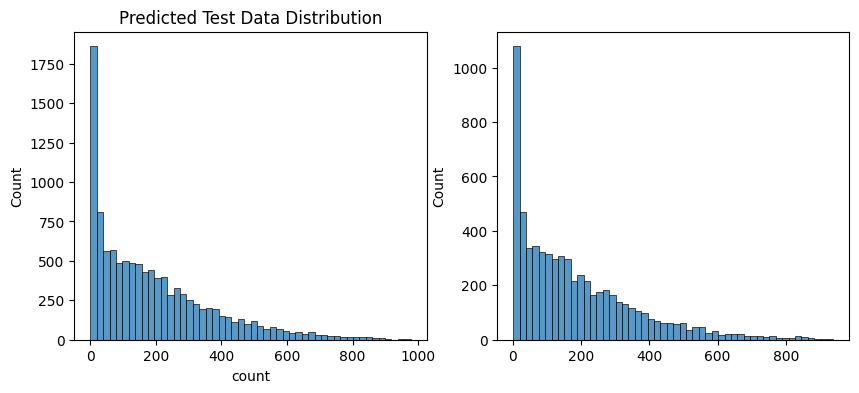

In [ ]:
figure, axes = plt.subplots(ncols=2)
figure.set_size_inches(10,4)

sns.histplot(y, bins=50, ax=axes[0])
axes[0].set_title('Train Data Distribution')

sns.histplot(np.exp(randomforest_preds), bins=50, ax=axes[1])
axes[0].set_title('Predicted Test Data Distribution')

In [ ]:
submission['count'] = np.exp(randomforest_preds)
submission.to_csv('submission.csv', index=False)